# **MÓDULO 13**
# Projeto - Fundamentos da Descoberta de Dados

Nesse projeto trabalharemos com a base de dados de produtos de um supermercado do Chile.
A ideia é que vocês apliquem os conceitos estatísticos vistos no último módulo, mais os conceitos de visualizações de dados através de gráficos e finalizem publicando no seu github!

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

Faça a leitura dos dados do arquivo CSV:


Altere o código abaixo de acordo com seu diretório.

In [25]:
df = df = pd.read_csv(r'C:\Users\bianc\PycharmProjects\PythonProject\.venv\Projetos EBAC\7. Estatística\MODULO7_PROJETOFINAL_BASE_SUPERMERCADO - MODULO7_PROJETOFINAL_BASE_SUPERMERCADO (1).csv')

df.head(10)

,title,Marca,Preco_Normal,Preco_Desconto,Preco_Anterior,Desconto,Categoria
0,"Pack 12 un, Leche extra proteína 1 L",Loncoleche,19788,0,0,0,lacteos
1,"Pack 12 un, Leche chocolate receta original 1 L",Soprole,18228,0,0,0,lacteos
2,"Pack 12 un, Leche semidescremada chocolate 1 L",Soprole,18228,0,0,0,lacteos
3,"Pack 12 un, Leche semidescremada frutilla 1 L",Soprole,18228,0,0,0,lacteos
4,"Pack 12 un, Leche sin lactosa chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
5,"Pack 12 un, Leche sin lactosa frutilla 1 L",Loncoleche,17988,0,0,0,lacteos
6,"Pack 12 un, Leche saborizada light chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
7,"Pack 12 un, Leche saborizada frutilla 1 L",Colun,17388,0,0,0,lacteos
8,"Pack 12 un, Leche saborizada vainilla 1 L",Colun,17388,0,0,0,lacteos
9,"Pack 12 un, Leche saborizada manjar 1 L",Colun,17388,0,0,0,lacteos


Os campos do nosso dataframe são:

**Title:** Nome do produto.


**Marca:** A marca do produto.


**Preco_Normal:** O preço em que o produto costuma ser vendido quando não há desconto.


**Preco_Desconto:** O preço vendido após o desconto ser aplicado.


**Preco_Anterior:** Preço em que era comercializado o produto antes do desconto aplicado.


**Desconto:** Total de desconto aplicado.






As colunas que aparecem com valores 0 são para os produtos onde não tivemos descontos aplicados.


As categorias estão em espanhol!

# 1 - Traga a média e a mediana dos preços - coluna Preco_Normal - por categoria de produto.
# Identifique as categorias que parecem ter um valor de média abaixo ou acima da mediana.

In [26]:
#Seu código aqui para a média
df.groupby('Categoria')['Preco_Normal'].mean().reset_index()

,Categoria,Preco_Normal
0,belleza-y-cuidado-personal,1783.556485
1,comidas-preparadas,3095.043478
2,congelados,2108.042553
3,frutas,1724.473684
4,instantaneos-y-sopas,765.491228
5,lacteos,2385.219239
6,verduras,1343.296875


In [27]:
#Seu código aqui para a mediana
df.groupby('Categoria')['Preco_Normal'].median().reset_index()

,Categoria,Preco_Normal
0,belleza-y-cuidado-personal,1569.0
1,comidas-preparadas,3290.0
2,congelados,1519.0
3,frutas,1195.0
4,instantaneos-y-sopas,439.0
5,lacteos,989.0
6,verduras,1180.0


In [28]:
categorias = df.groupby('Categoria')['Preco_Normal'].agg(['mean', 'median']).reset_index()

categorias['relação'] = categorias.apply(
    lambda x: 'acima da mediana' if x['mean'] > x['median']
    else 'abaixo da mediana' if x['mean'] < x['median']
    else 'igual à mediana',
    axis=1
)

print(categorias)

                    Categoria         mean  median            relação
0  belleza-y-cuidado-personal  1783.556485  1569.0   acima da mediana
1          comidas-preparadas  3095.043478  3290.0  abaixo da mediana
2                  congelados  2108.042553  1519.0   acima da mediana
3                      frutas  1724.473684  1195.0   acima da mediana
4        instantaneos-y-sopas   765.491228   439.0   acima da mediana
5                     lacteos  2385.219239   989.0   acima da mediana
6                    verduras  1343.296875  1180.0   acima da mediana


Digite aqui as categorias:

A única categoria com média abaixo da mediana é a comidas-preparadas, enquanto todas as outras estão com média acima da mediana.

# 2 - Traga o desvio padrão por categoria de produto.
# Qual o comportamento da média e mediana nas categorias com maior desvio?

In [29]:
#Seu código aqui
df.groupby('Categoria')['Preco_Normal'].std().reset_index()

,Categoria,Preco_Normal
0,belleza-y-cuidado-personal,2210.041719
1,comidas-preparadas,2019.911428
2,congelados,2111.539896
3,frutas,1639.151114
4,instantaneos-y-sopas,1170.232869
5,lacteos,3925.816164
6,verduras,1012.699625


In [30]:
df.groupby('Categoria')['Preco_Normal'].agg(['mean', 'median','std']).reset_index()

,Categoria,mean,median,std
0,belleza-y-cuidado-personal,1783.556485,1569.0,2210.041719
1,comidas-preparadas,3095.043478,3290.0,2019.911428
2,congelados,2108.042553,1519.0,2111.539896
3,frutas,1724.473684,1195.0,1639.151114
4,instantaneos-y-sopas,765.491228,439.0,1170.232869
5,lacteos,2385.219239,989.0,3925.816164
6,verduras,1343.296875,1180.0,1012.699625


Digite nesse campo o comportamento que você identificou.

Percebe-se que a distrubuição dos preços por categorias tem grande variação. Na maioria das categorias, o desvio demonstra preços 100% maiores do que a média ou mediana, o que significa que há produtos com valores bem reduzidos e outros bem elevados. A categoria com maior desvio padrão é a lacteos, com um desvio quase 4x maior que a mediana.

# 3 - Plot um boxplot da distribuição do Preco_Normal para a categoria que você identificou que tem o maior desvio padrão. Como é a distribuição desses dados segundo o boxplot? Você identifica muitos outliers?

Dica: Para trazer apenas os dados da categoria que você deseja você pode usar o df.loc[df['Categoria'] == 'CATEGORIA ESCOLHIDA'

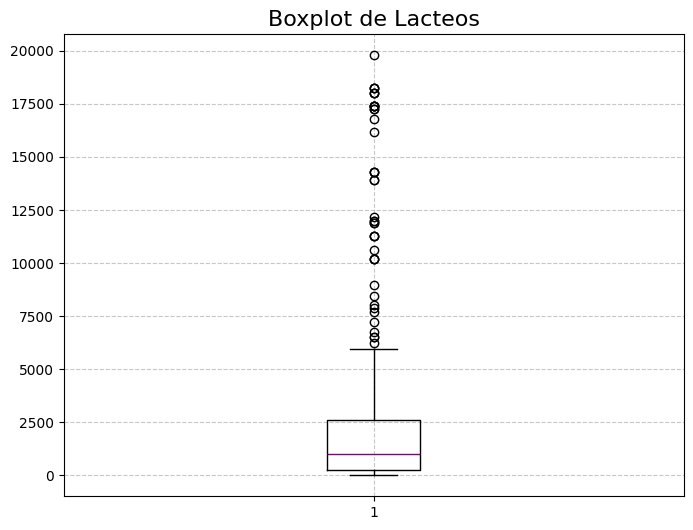

In [31]:
#Seu código aqui
lacteos = df.loc[df['Categoria']=='lacteos']
plt.figure(figsize=(8,6))
plt.boxplot(lacteos['Preco_Normal'], vert=True, medianprops={'color':'purple'})
plt.title('Boxplot de Lacteos',fontsize=16)
plt.grid(True,linestyle='--',alpha=0.7)
plt.show()

É uma distribuição muito variada, como mencionada no exercício anterior. A categoria lacteos apresenta outliers com valores 10 vezes maiores do que a média de preços normais. Além dessa clara distância entre valores, é perceptível também a presença de diversos outliers acima do boxplot.

# 4 - Plote um gráfico de barras onde temos a média de descontos por categoria.

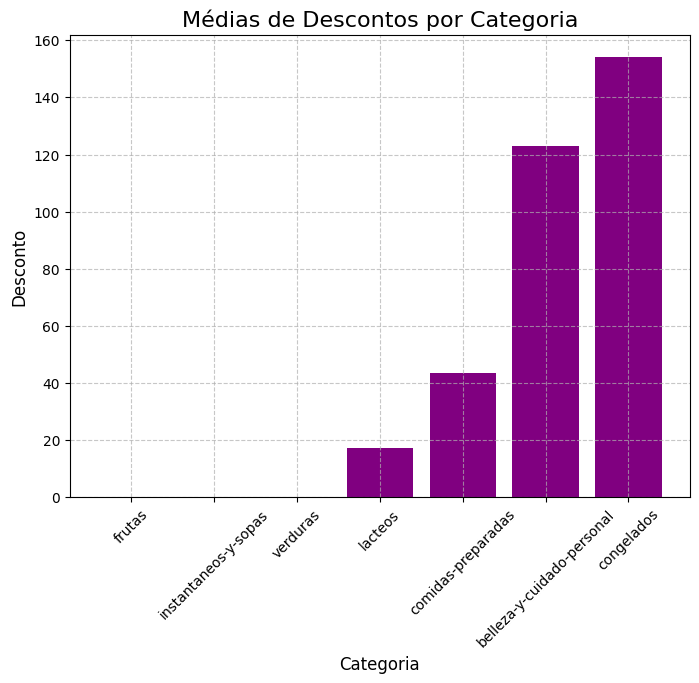

In [32]:
# Seu código aqui
plt.figure(figsize=(8,6))

descontos_categoria = df.groupby('Categoria')['Desconto'].mean().sort_values(ascending=True)

plt.bar(descontos_categoria.index, descontos_categoria, color='purple')
plt.title('Médias de Descontos por Categoria', fontsize=16)
plt.xlabel('Categoria', fontsize=12)
plt.ylabel('Desconto', fontsize=12)
plt.xticks(rotation=45)
plt.grid(True,linestyle='--',alpha=0.7)
plt.show()

# 5 - Plote um gráfico de mapa interativo agrupando os dados por categoria, marca e trazendo a média de desconto.

In [33]:
# Seu código aqui
categoria_marca_desconto = df.groupby(['Categoria','Marca'])['Desconto'].mean().reset_index()

fig = px.treemap(categoria_marca_desconto,
                 path=['Categoria','Marca'],
                 values='Desconto',
                 title='Média de Desconto por Categoria e Marca',
                 color='Marca')
fig.show()